### #2 improvements
 - improve cutting out of mesh from uniform grid (no more external points) (get_grid_surface2())
 - same curvature values for every pose (poly fitted in neutral and interceps are transformed back to neutral)
 - n points per mm^2 () (get_grid_surface2() / get_grid2())
 - get congruence of every pose?

### #3 improvements
 - fit poynomial in centre norm based coordinate system for both surfaces (then transform interception points accordingly)

### #4 improvements
 - tried switching to trimesh for ray trace (*** something about how pyvista calculates ray_trace has broken in wristrepair environment - now 50x slower on mac) but trimesh was still slow
 - had to make new environment and keep using pyvista - TMCshape
 - changed get_intercepts so ray_start points are now 10 units further from mc1 so that areas that interfere are picked up
 - added option to 'normalise' or 'scale' k

### #5 improvements
 - (a) new congruence metric based on difference between shape operater matrices at each point (could do demonstration of C value for difference scenarios to better understand)
 - (b) new congruence metric based on both principal curvatures 

### Future improvements
 - equalateral mesh instead of grid for better uniform point density


In [1]:
import os
import numpy as np
import pandas as pd
import pyvista as pv
from tqdm import tqdm
from scipy.spatial.distance import cdist

from phd_helpers.helpers import (
    get_info_dict, change_coord, get_motion_paths, get_bone_motions, get_relative_motion_new_coords,
    get_motion_mesh, get_axes_from_normal
)
from phd_helpers.SurfaceFit import (
    get_grid_surface2, get_sp_terms, get_f, get_ks_eig, get_poly_normals, 
    get_centroid, get_intercepts
)
from phd_helpers.helpers2 import get_info_path, get_db_path

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def get_polynomial_model(mesh, degree=5):
    points = mesh.points
    xs, ys, zs = points[:, 0], points[:, 1], points[:, 2]
    XY = np.vstack((xs, ys)).T

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    XY_poly = poly.fit_transform(XY) # 21 coefs for 5th degree polynomial
    model = LinearRegression(fit_intercept=True)
    model.fit(XY_poly, zs)

    # fit quality
    z_pred = model.predict(XY_poly)
    r2 = r2_score(zs, z_pred)
    rmse = np.sqrt(mean_squared_error(zs, z_pred))
    #print(f"Polynomial fit quality: R² = {r2:.4f}, RMSE = {rmse:.4f}")
    return model, poly, r2, rmse

def get_Ck(saddle_ks, mc1_ks, intercept_dists, d0=0.1):
    """get curvature congruence"""
    k1_T = saddle_ks['kmax']
    k2_T = saddle_ks['kmin']
    k1_M = mc1_ks['kmin']
    k2_M = mc1_ks['kmax']

    Cs = np.sqrt( ((k1_T+k1_M)**2 + (k2_T+k2_M)**2) / 2 )

    # d0 stops weights from blowing up due to interference
    weights = 1.0 / (intercept_dists + d0)
    weights /= weights.sum()          # normalize

    C_avg = np.sum(weights * Cs)
    return C_avg

def get_Cv(saddle_ks, mc1_ks, intercept_dists, d0=0.1):
    """get vector congruence"""
    v1_T = saddle_ks['kmax_dir']
    v2_T = saddle_ks['kmin_dir']
    v1_M = mc1_ks['kmin_dir']
    v2_M = mc1_ks['kmax_dir']

    # squared cosines (sign-invariant)
    C1s = np.sum(v1_T * v1_M, axis=1)**2
    C2s = np.sum(v2_T * v2_M, axis=1)**2
    Cs = 0.5 * (C1s + C2s)

    # d0 stops weights from blowing up due to interference
    weights = 1.0 / (intercept_dists + d0)
    weights /= weights.sum()          # normalize

    C_avg = np.sum(weights * Cs)
    return C_avg
######################## Maybe do hard cutoff at d = 0.1?  
# - where they interfere points that are through surface are further but should be closer

In [50]:
info = pd.read_csv(get_info_path())
db_path = get_db_path()
savename = 'TMC-SurfaceFit9_noscaling.csv' ######### ------------ CHANGE ------------ ######### 

mc1_base_path = '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/KineticsData/mc1-base-meshes2'
mc1_mesh_files = [x for x in os.listdir(mc1_base_path) if '.vtk' in x]
print(len(mc1_mesh_files), 'mc1s')

saddle_mesh_path = '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/KineticsData/saddle-meshes2'
#saddle_mesh_path = '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/KineticsData/ideal-saddle'
saddle_mesh_files = [x for x in os.listdir(saddle_mesh_path) if '.vtk' in x]
print(len(saddle_mesh_files), 'saddles')

46 mc1s
46 saddles


In [ ]:
poly_degree = 5
mc1_grid_points = 200 # points / mm^2
saddle_grid_points = 200 # points / mm^2
n = 200 # points in rmsd neighbourhood
n_joints = len(saddle_mesh_files)
scale_k = 'scale' # set to either 'scale' or 'normalise' or anything else

poses = ['neutral', 'flexion', 'extension', 'abduction', 'adduction', 'pinch', 'grasp', 'jar', 'pinch_load', 'grasp_load', 'jar_load']
pose_ids = [-1, 2, 3, 1, 0, 4, 6, 8, 5, 7, 9] # -1 placeholder for neutral, flexion, extension, abduction, adduction
#poses = ['pinch', 'grasp', 'jar']
#pose_ids = [4, 6, 8]
#poses = ['neutral', 'flexion'] 
#pose_ids = [-1, 2]

data = info.copy()[info['group']=='CMC']
for k in ['tpm_kmin', 'tpm_kmax', 'mc1_kmin', 'mc1_kmax']:
    data[k] = np.zeros(n_joints)
for pose in poses:
    data[f'Ck_{pose}'] = np.zeros(n_joints)
    data[f'Cv_{pose}'] = np.zeros(n_joints)
data['tpm_r2'] = np.zeros(n_joints)
data['tpm_rmse'] = np.zeros(n_joints)
data['mc1_r2'] = np.zeros(n_joints)
data['mc1_rmse'] = np.zeros(n_joints)

vol_mean = data['tpm_volume'].mean()
for i in tqdm(range(n_joints)):
    # get saddle mesh
    saddle_file = saddle_mesh_files[i]
    #saddle_file = [x for x in saddle_mesh_files if '14727' in x and 'R' in x][0]
    #saddle_file = [x for x in saddle_mesh_files if '15285' in x and 'R' in x][0]

    saddle_filepath = os.path.join(saddle_mesh_path, saddle_file)
    saddle_mesh = pv.read(saddle_filepath).extract_geometry()
    # get subject info
    subject_info = get_info_dict(info, saddle_file.split('-')[0], saddle_file.split('-')[1])[0]
    # get mc1 mesh
    mc1_file = [x for x in mc1_mesh_files if str(subject_info['subject']) in x and subject_info['side'] in x][0]
    mc1_filepath = os.path.join(mc1_base_path, mc1_file)
    mc1_neutral_mesh = pv.read(mc1_filepath).extract_geometry()


    # get saddle normal based axes - **** could determine orientation that minimises z gradients? ****
    saddle_centre_idx = saddle_mesh.find_closest_point(get_centroid(saddle_mesh.faces.reshape(-1, 4), saddle_mesh.points))
    saddle_centre_norm = saddle_mesh.compute_normals(point_normals=True, cell_normals=False).point_data["Normals"][saddle_centre_idx]
    saddle_norm_axes = get_axes_from_normal(saddle_centre_norm*(-1))
    saddle_norm_origin = saddle_mesh.points[saddle_centre_idx] - 5 * saddle_centre_norm # 5 is avg norm of: saddle_centre - tpm_centroid
    # get mc1 normal based axes
    mc1_centre_idx = mc1_neutral_mesh.find_closest_point(get_centroid(mc1_neutral_mesh.faces.reshape(-1, 4), mc1_neutral_mesh.points))
    mc1_centre_norm = mc1_neutral_mesh.compute_normals(point_normals=True, cell_normals=False).point_data["Normals"][mc1_centre_idx]
    mc1_norm_axes = get_axes_from_normal(mc1_centre_norm*(-1))
    mc1_norm_origin = mc1_neutral_mesh.points[mc1_centre_idx] - 5 * mc1_centre_norm # 5 is avg norm of: saddle_centre - tpm_centroid
    # change to centre normal based coordinate system for good polynomial fit
    saddle_mesh.points = change_coord(saddle_mesh.points, saddle_norm_origin, saddle_norm_axes)
    mc1_neutral_mesh.points = change_coord(mc1_neutral_mesh.points, mc1_norm_origin, mc1_norm_axes)


    # fit models
    saddle_model, saddle_poly, saddle_r2, saddle_rmse = get_polynomial_model(saddle_mesh, degree=poly_degree)
    mc1_model, mc1_poly, mc1_r2, mc1_rmse = get_polynomial_model(mc1_neutral_mesh, degree=poly_degree)
    data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),'tpm_r2']=saddle_r2
    data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),'tpm_rmse']=saddle_rmse
    data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),'mc1_r2']=mc1_r2
    data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),'mc1_rmse']=mc1_rmse

    # get grid of x, y points within bounds of mesh
    mc1_grid_surface_neutral = get_grid_surface2(mc1_neutral_mesh, mc1_model, mc1_poly, grid_points=mc1_grid_points)
    saddle_grid_surface = get_grid_surface2(saddle_mesh, saddle_model, saddle_poly, grid_points=saddle_grid_points)

    # Evaluate curvatures on the evenly spaced grids
    saddle_terms = get_sp_terms(saddle_poly)
    saddle_f = get_f(saddle_model, saddle_terms)
    saddle_ks = get_ks_eig(saddle_f, saddle_grid_surface.points)
    if scale_k == 'normalise':
        saddle_ks['kmin'] = saddle_ks['kmin'] * subject_info['tpm_volume']**(1/3) ######### normalise ###########
        saddle_ks['kmax'] = saddle_ks['kmax'] * subject_info['tpm_volume']**(1/3) ######### normalise ###########
    elif scale_k == 'scale':
        saddle_ks['kmin'] = saddle_ks['kmin'] / (vol_mean / subject_info['tpm_volume'])**(1/3) ######### normalise ###########
        saddle_ks['kmax'] = saddle_ks['kmax'] / (vol_mean / subject_info['tpm_volume'])**(1/3) ######### normalise ###########
        
    saddle_grid_surface["kmin_dir"] = saddle_ks['kmin_dir']
    saddle_grid_surface["kmax_dir"] = saddle_ks['kmax_dir']
    saddle_grid_surface["kmin"] = saddle_ks['kmin']
    saddle_grid_surface["kmax"] = saddle_ks['kmax']

    mc1_terms = get_sp_terms(mc1_poly)
    mc1_f = get_f(mc1_model, mc1_terms)
    mc1_ks = get_ks_eig(mc1_f, mc1_grid_surface_neutral.points)
    if scale_k == 'normalise':
        mc1_ks['kmin'] = mc1_ks['kmin'] * subject_info['tpm_volume']**(1/3) ######### normalise ###########
        mc1_ks['kmax'] = mc1_ks['kmax'] * subject_info['tpm_volume']**(1/3) ######### normalise ###########
    elif scale_k == 'scale':
        mc1_ks['kmin'] = mc1_ks['kmin'] / (vol_mean / subject_info['tpm_volume'])**(1/3) ######### normalise ###########
        mc1_ks['kmax'] = mc1_ks['kmax'] / (vol_mean / subject_info['tpm_volume'])**(1/3) ######### normalise ###########

    mc1_grid_surface_neutral["kmin_dir"] = mc1_ks['kmin_dir']
    mc1_grid_surface_neutral["kmax_dir"] = mc1_ks['kmax_dir']
    mc1_grid_surface_neutral["kmin"] = mc1_ks['kmin']
    mc1_grid_surface_neutral["kmax"] = mc1_ks['kmax']


    # get average kmins and kmaxs
    tpm_kmin = np.mean(saddle_ks['kmin'])
    tpm_kmax = np.mean(saddle_ks['kmax'])
    mc1_kmin = np.mean(mc1_ks['kmin'])
    mc1_kmax = np.mean(mc1_ks['kmax'])
    data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),'tpm_kmin']=tpm_kmin
    data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),'tpm_kmax']=tpm_kmax
    data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),'mc1_kmin']=mc1_kmin
    data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),'mc1_kmax']=mc1_kmax

    # get saddle normals
    saddle_grid_normals = get_poly_normals(saddle_f, saddle_grid_surface.points)

    # change surface mesh coords back to global frame for calculating intercepts
    saddle_grid_surface.points = change_coord(saddle_grid_surface.points, saddle_norm_origin, saddle_norm_axes, inverse=True)
    mc1_grid_surface_neutral.points = change_coord(mc1_grid_surface_neutral.points, mc1_norm_origin, mc1_norm_axes, inverse=True)
    saddle_grid_surface_points = saddle_grid_surface.points
    saddle_grid_normals = change_coord(saddle_grid_normals, np.zeros(3), saddle_norm_axes, inverse=True)

    # get motion info
    stl_path = os.path.join(db_path, subject_info['path'])
    subject_path = stl_path.replace('/'+stl_path.split('/')[-1], '')
    motion_paths = get_motion_paths(subject_path, subject_info['side'])

    for j in range(len(poses)):
        #j = 6
        
        if pose_ids[j] == -1: # neutral
            R_rel, t_rel = np.eye(3), np.zeros(3)
            mc1_grid_surface = mc1_grid_surface_neutral.copy(deep=True)
        else:
            motions = get_bone_motions(pose_ids[j], motion_paths)
            R_rel, t_rel = get_relative_motion_new_coords(motions, 'mc1', 'tpm') # global
            mc1_grid_surface = get_motion_mesh(mc1_grid_surface_neutral.copy(deep=True), R_rel, t_rel)


        # find intercepts
        mc1_grid_intercepts, saddle_grid_intercepts, intercept_mask = get_intercepts(
                                                                                mc1_grid_surface, 
                                                                                saddle_grid_surface_points, 
                                                                                saddle_grid_normals,
                                                                                offset=10
                                                                                )
        
        # get distances between intercept points before converting to neutral pose coords
        intercept_dists = np.linalg.norm(saddle_grid_intercepts - mc1_grid_intercepts, axis=1)
        # convert back to neutral pose coords
        mc1_grid_intercepts = change_coord(mc1_grid_intercepts, t_rel, R_rel)
        # convert back to centre normal based coords
        saddle_grid_intercepts = change_coord(saddle_grid_intercepts, saddle_norm_origin, saddle_norm_axes)
        mc1_grid_intercepts = change_coord(mc1_grid_intercepts, mc1_norm_origin, mc1_norm_axes)


        # get ks of intercepts
        saddle_intercept_ks = get_ks_eig(saddle_f, saddle_grid_intercepts)
        mc1_intercept_ks = get_ks_eig(mc1_f, mc1_grid_intercepts)

        if scale_k == 'normalise':
            saddle_intercept_ks['kmax'] = saddle_intercept_ks['kmax'] * subject_info['tpm_volume']**(1/3) ######### normalise ###########
            saddle_intercept_ks['kmin'] = saddle_intercept_ks['kmin'] * subject_info['tpm_volume']**(1/3) ######### normalise ###########
            mc1_intercept_ks['kmax'] = mc1_intercept_ks['kmax'] * subject_info['tpm_volume']**(1/3) ######### normalise ###########
            mc1_intercept_ks['kmin'] = mc1_intercept_ks['kmin'] * subject_info['tpm_volume']**(1/3) ######### normalise ###########
        elif scale_k == 'scale':
            saddle_intercept_ks['kmax'] = saddle_intercept_ks['kmax'] / (vol_mean / subject_info['tpm_volume'])**(1/3) ######### normalise ###########
            saddle_intercept_ks['kmin'] = saddle_intercept_ks['kmin'] / (vol_mean / subject_info['tpm_volume'])**(1/3) ######### normalise ###########
            mc1_intercept_ks['kmax'] = mc1_intercept_ks['kmax'] / (vol_mean / subject_info['tpm_volume'])**(1/3) ######### normalise ###########
            mc1_intercept_ks['kmin'] = mc1_intercept_ks['kmin'] / (vol_mean / subject_info['tpm_volume'])**(1/3) ######### normalise ###########

        # convert k vectors back to global posed coords
        saddle_intercept_ks['kmax_dir'] = change_coord(saddle_intercept_ks['kmax_dir'], np.zeros(3), saddle_norm_axes, inverse=True)
        saddle_intercept_ks['kmin_dir'] = change_coord(saddle_intercept_ks['kmin_dir'], np.zeros(3), saddle_norm_axes, inverse=True)

        mc1_intercept_ks['kmax_dir'] = change_coord(mc1_intercept_ks['kmax_dir'], np.zeros(3), mc1_norm_axes, inverse=True)
        mc1_intercept_ks['kmin_dir'] = change_coord(mc1_intercept_ks['kmin_dir'], np.zeros(3), mc1_norm_axes, inverse=True)
        mc1_intercept_ks['kmax_dir'] = change_coord(mc1_intercept_ks['kmax_dir'], np.zeros(3), R_rel, inverse=True)
        mc1_intercept_ks['kmin_dir'] = change_coord(mc1_intercept_ks['kmin_dir'], np.zeros(3), R_rel, inverse=True)

        Ck = get_Ck(saddle_intercept_ks, mc1_intercept_ks, intercept_dists) # curvature congruence
        Cv = get_Cv(saddle_intercept_ks, mc1_intercept_ks, intercept_dists) # vector congruence

        # get local averages of k_diff and weights
        #rmsd_dists = cdist(saddle_grid_surface_points[intercept_mask], saddle_grid_surface_points[intercept_mask], 'euclidean') # dists of every saddle point to every saddle point
        #rmsd_closest_idxs = np.argsort(rmsd_dists, axis=1)[:, :n] # returns idxs of n closest saddle points including point
        #weights_avg = np.mean(weights[rmsd_closest_idxs], axis=1)
        

        data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),f'Ck_{poses[j]}']=Ck
        data.loc[(data.subject==subject_info['subject'])&(data.side==subject_info['side']),f'Cv_{poses[j]}']=Cv
    #data.to_csv(savename, index=False)


100%|██████████| 46/46 [2:12:27<00:00, 172.77s/it]


In [ ]:
(make sure ray trace steps in right direction)

In [ ]:
data.to_csv(savename, index=False)
data = pd.read_csv(savename).sort_values(['subject', 'side']).reset_index(drop=True)


In [ ]:
Cv_data = data[[x for x in data.columns if 'Cv_' in x]]
Ck_data = data[[x for x in data.columns if 'Ck_' in x]]
Ck_med = np.median(Ck_data.values.flatten())

Ck_score = 1 / (1+(Ck_data/Ck_med))
C = (Ck_score.values*Cv_data.values)**(0.5)
data[[x.replace('Ck_', 'C_') for x in Ck_data.columns]] = C

In [48]:
data['C_avg'] = data[['C_'+x for x in poses]].mean(axis=1)
data['C_fe'] = data[['C_flexion', 'C_extension']].mean(axis=1)
data['C_aa'] = data[['C_abduction', 'C_adduction']].mean(axis=1)
data.to_csv(savename, index=False)

In [49]:
SurfaceFitdf9 = pd.read_csv('TMC-SurfaceFit9.csv') # New congruence metric (first of SFL-5b)
SurfaceFitdf9 # grid = 200, n = 200, scaled k

,group,subject,sex,age,side,path,tpm_volume,tpm_kmin,tpm_kmax,mc1_kmin,...,C_adduction,C_pinch,C_grasp,C_jar,C_pinch_load,C_grasp_load,C_jar_load,C_avg,C_fe,C_aa
0,CMC,14548,F,25,R,CMC_Tasks/Young/Female/14548/RightSTL,1440.57,-0.067296,0.161986,-0.051412,...,0.596549,0.614589,0.676379,0.652214,0.602933,0.699901,0.673553,0.645208,0.640099,0.629971
1,CMC,14613,M,52,R,CMC_Tasks/Old/Male/14613/RightSTL,3184.63,-0.058498,0.119960,-0.085605,...,0.648676,0.692221,0.650666,0.702167,0.691135,0.682652,0.696637,0.680178,0.688648,0.653268
2,CMC,14685,F,23,R,CMC_Tasks/Young/Female/14685/RightSTL,2005.73,-0.072100,0.178106,-0.073105,...,0.590141,0.629582,0.645686,0.616674,0.627518,0.690508,0.629922,0.635856,0.643931,0.606499
3,CMC,14726,M,48,R,CMC_Tasks/Old/Male/14726/RightSTL,3500.61,-0.075875,0.130703,-0.052299,...,0.635112,0.651893,0.662123,0.685864,0.638988,0.672208,0.670500,0.662128,0.674032,0.637718
4,CMC,14727,F,47,R,CMC_Tasks/Old/Female/14727/RightSTL,2320.74,-0.051320,0.170361,-0.095304,...,0.667100,0.653611,0.604810,0.606150,0.618686,0.640740,0.588829,0.637574,0.667261,0.661451
5,CMC,14818,F,24,R,CMC_Tasks/Young/Female/14818/RightSTL,1753.40,-0.048495,0.169315,-0.052941,...,0.593976,0.588186,0.608386,0.602531,0.553865,0.626763,0.610558,0.594971,0.590058,0.590316
6,CMC,14819,M,25,R,CMC_Tasks/Young/Male/14819/RightSTL,1998.23,-0.076729,0.140710,-0.044752,...,0.698665,0.677937,0.690449,0.676017,0.693845,0.692810,0.684012,0.683497,0.670070,0.689461
7,CMC,14827,F,20,L,CMC_Tasks/Young/Female/14827/LeftSTL,1388.37,-0.063573,0.159568,-0.052229,...,0.611166,0.650679,0.664073,0.660733,0.635039,0.658169,0.538058,0.637482,0.644163,0.626156
8,CMC,14873,M,23,R,CMC_Tasks/Young/Male/14873/RightSTL,2823.84,-0.071738,0.161735,-0.069507,...,0.639495,0.613284,0.642206,0.628499,0.601394,0.627906,0.634987,0.632656,0.646446,0.635914
9,CMC,14874,F,54,R,CMC_Tasks/Old/Female/14874/RightSTL,1437.32,-0.042214,0.147120,-0.037565,...,0.580198,0.637592,0.645599,0.644160,0.622544,0.647480,0.629396,0.615702,0.579435,0.578840


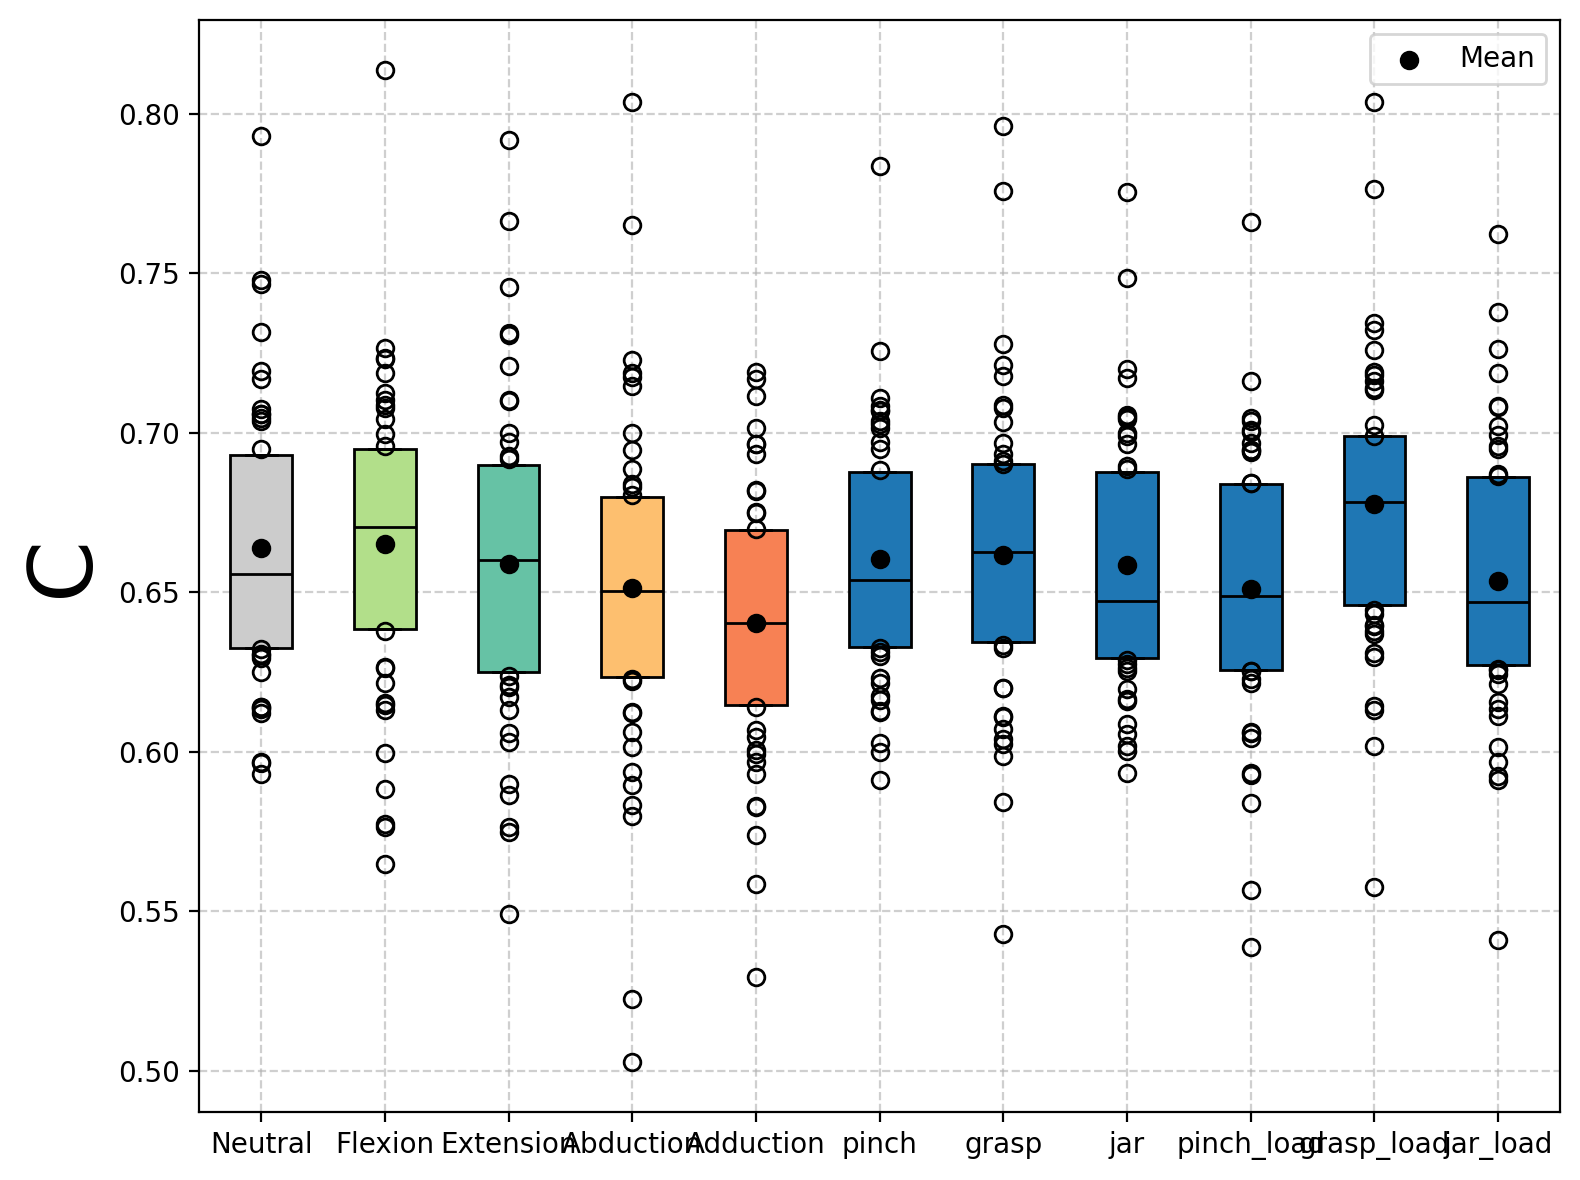

In [12]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from phd_helpers.helpers2 import get_hex
cdf = pd.read_csv('/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/KineticsData/pastel_palette.csv')

s = 25
fs_l = 32
fs_t = 10
figsize=(6, 4)
locx, locy = 0.72, 0.08 # correlation coeff label location

# 9 #
pose_labels = [
    'Neutral',
    'Flexion', 
    'Extension', 
    'Abduction', 
    'Adduction', 
    'pinch', 
    'grasp', 
    'jar', 
    'pinch_load', 
    'grasp_load', 
    'jar_load'
    ]
pose_data = SurfaceFitdf9.iloc[:, -14:-3]

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

box = ax.boxplot(pose_data, patch_artist=True, tick_labels=pose_labels, whis=[25, 75])# whis=[0, 100] (min and max) shows full range

# median line color
for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(1)
# box colors
colors = [get_hex('grey1', cdf), get_hex('green1', cdf), get_hex('green2', cdf), get_hex('orange1', cdf), get_hex('orange2', cdf)]
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# means
means = pose_data.mean().values
ax.scatter(range(1, len(means) + 1), means, color='black', label='Mean', zorder=10)

#ax.set_xlabel('Pose', fontsize=fs_l)
ax.set_ylabel(r'C', fontsize=fs_l)
ax.legend(fontsize=fs_t)
ax.grid(True, linestyle='--', alpha=0.6)

ax.tick_params(axis='both', which='major', labelsize=fs_t)

plt.tight_layout()


#plt.savefig(savepath+'/WWL-RMSDboxplot',bbox_inches='tight')

In [19]:
SurfaceFitdf9[SurfaceFitdf9['C_abduction']<0.55].iloc[:, 15:25]

,Ck_extension,Cv_extension,Ck_abduction,Cv_abduction,Ck_adduction,Cv_adduction,Ck_pinch,Cv_pinch,Ck_grasp,Cv_grasp
10,0.126328,0.839072,0.120866,0.642159,0.105930,0.719348,0.109690,0.836056,0.103432,0.782494
14,0.100545,0.772796,0.122335,0.598459,0.103718,0.831951,0.074271,0.850496,0.104602,0.639371


In [22]:
SurfaceFitdf9[[x for x in SurfaceFitdf9 if 'C_' in x]].mean(axis=0)

C_neutral       0.663913
C_flexion       0.665172
C_extension     0.658682
C_abduction     0.651246
C_adduction     0.640414
C_pinch         0.660237
C_grasp         0.661599
C_jar           0.658402
C_pinch_load    0.651084
C_grasp_load    0.677566
C_jar_load      0.653554
C_avg           0.658352
C_fe            0.661927
C_aa            0.645830
dtype: float64

In [13]:
SurfaceFitdf9[[x for x in SurfaceFitdf9.columns if 'C_' in x][:-3]].corr().min()

C_neutral       0.603050
C_flexion       0.390223
C_extension     0.554897
C_abduction     0.472416
C_adduction     0.317197
C_pinch         0.530075
C_grasp         0.337051
C_jar           0.483564
C_pinch_load    0.510452
C_grasp_load    0.317197
C_jar_load      0.414313
dtype: float64

PearsonRResult(statistic=np.float64(0.3171965290899149), pvalue=np.float64(0.031718921145092595))


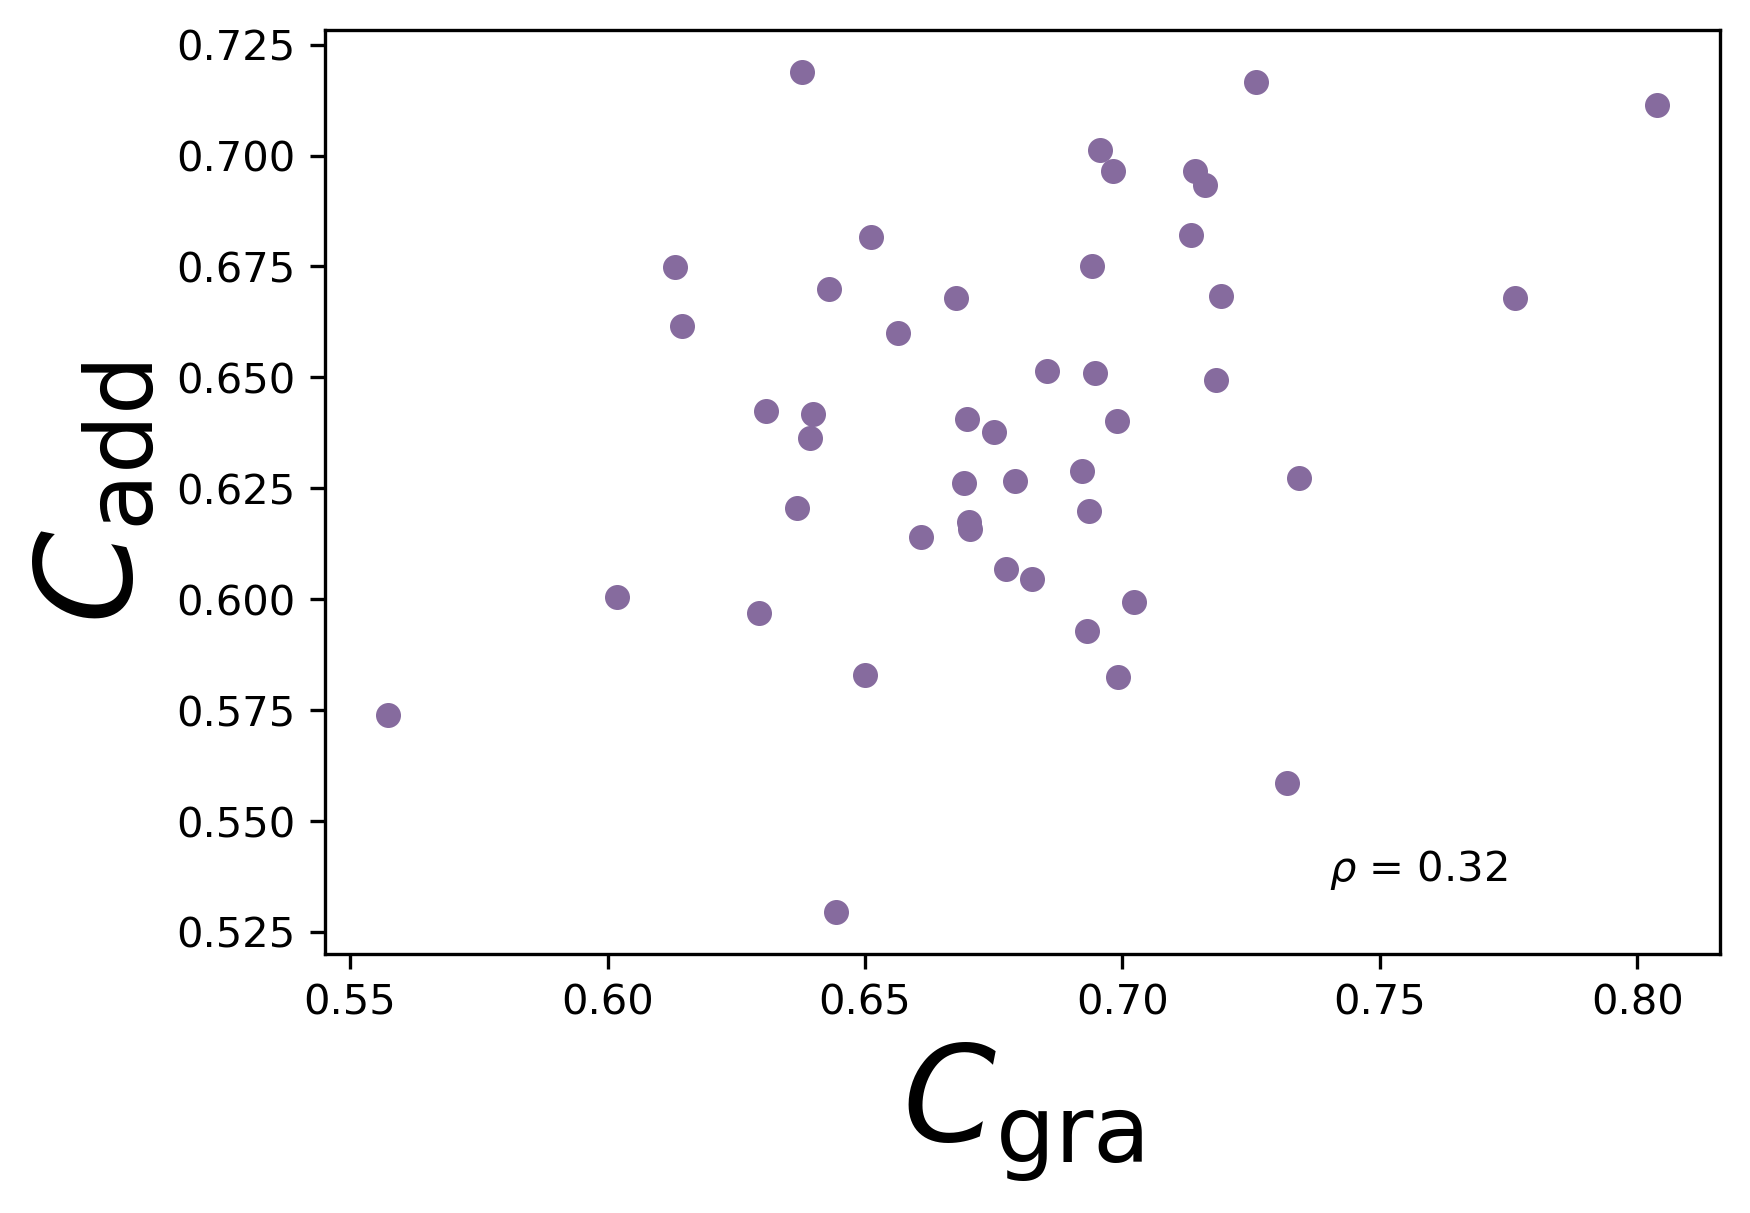

In [14]:
# not in transfer

fig, ax = plt.subplots(figsize=figsize, dpi=300)

x, y = SurfaceFitdf9['C_grasp_load'], SurfaceFitdf9['C_adduction']
ax.scatter(x, y, s=s, color="#866b9e")
ax.set_xlabel(r'$C_{\text{gra}}$', fontsize=fs_l)
ax.set_ylabel(r'$C_{\text{add}}$', fontsize=fs_l)

xlims, ylims = ax.get_xlim(), ax.get_ylim()
xdiff, ydiff = xlims[1] - xlims[0], ylims[1] - ylims[0]
loc = [xlims[0] + xdiff*locx, ylims[0] + ydiff*locy]
ax.annotate(r'$\rho$ ='+f'{pearsonr(x, y)[0] : .2f}', loc, fontsize=fs_t)
print(pearsonr(x, y))

ax.tick_params(axis='both', which='major', labelsize=fs_t)

In [25]:
SurfaceFitdf9[SurfaceFitdf9['C_grasp']<0.5]

,group,subject,sex,age,side,path,tpm_volume,tpm_kmin,tpm_kmax,mc1_kmin,...,C_adduction,C_pinch,C_grasp,C_jar,C_pinch_load,C_grasp_load,C_jar_load,C_avg,C_fe,C_aa
4,CMC,14727,F,47,R,CMC_Tasks/Old/Female/14727/RightSTL,2320.74,-0.051320,0.170361,-0.095304,...,0.670333,0.657066,0.407196,0.58375,0.616450,0.636039,0.387540,0.667290,0.670908,0.663672
14,CMC,15285,M,25,R,CMC_Tasks/Young/Male/15285/RightSTL,2009.09,-0.051352,0.132999,-0.049275,...,0.620223,0.683518,0.446423,0.58166,0.629124,0.633737,0.734571,0.568423,0.628111,0.508735


In [14]:
pl = pv.Plotter()

pl.add_mesh(saddle_grid_surface, scalars='kmax')
pl.add_mesh(mc1_grid_surface, scalars=mc1_grid_surface_neutral['kmin'])

pl.show()

Widget(value='<iframe src="http://localhost:62331/index.html?ui=P_0x30f3d46b0_1&reconnect=auto" class="pyvista…

# Experiment with s value
- think median looks best

In [ ]:
Ck_data = SurfaceFitdf9[[x for x in SurfaceFitdf9.columns if 'Ck_' in x]]
Ck_flat = Ck_data.values.flatten()
Ck_pct = np.median(Ck_flat) 
Ck_score = 1 / (1+(Ck_data/Ck_pct))

10-IQR: 0.0657 R: 0.3042
20-IQR: 0.0664 R: 0.3050
30-IQR: 0.0667 R: 0.3049
40-IQR: 0.0668 R: 0.3045
50-IQR: 0.0669 R: 0.3038
60-IQR: 0.0668 R: 0.3025
70-IQR: 0.0667 R: 0.3005
80-IQR: 0.0664 R: 0.2981
90-IQR: 0.0661 R: 0.2959
100-IQR: 0.0632 R: 0.2791


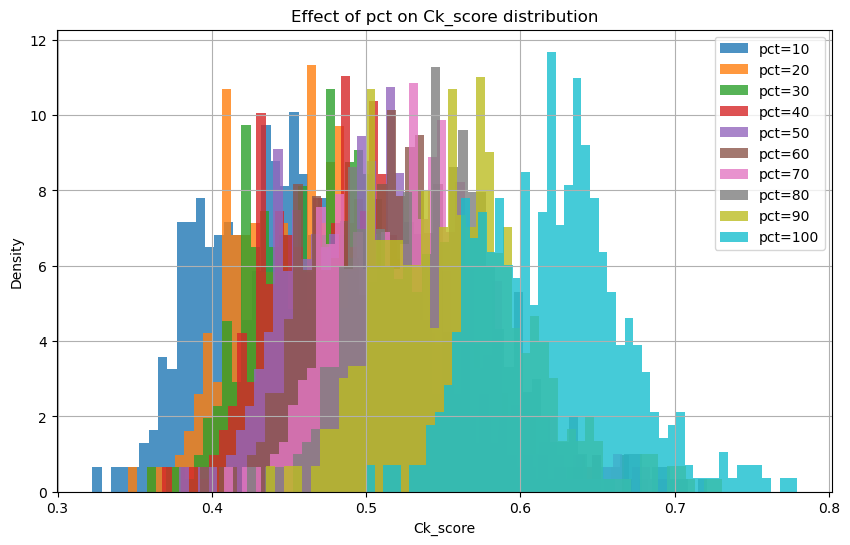

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Extract and flatten Ck data
Ck_data = SurfaceFitdf9[[x for x in SurfaceFitdf9.columns if 'Ck_' in x]]
Ck_flat = Ck_data.values.flatten()

# Percentiles to test
pcts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

plt.figure(figsize=(10, 6))

for pct in pcts:
    s = np.percentile(Ck_flat, pct)
    Ck_score = 1 / (1 + (Ck_data / s))
    Ck_score_flat = Ck_score.values.flatten()

    print(f'{pct}-IQR: {np.percentile(Ck_score, 75)-np.percentile(Ck_score, 25):.4f}', f'R: {np.max(Ck_score)-np.min(Ck_score):.4f}')

    # Plot distribution
    plt.hist(Ck_score_flat, bins=50, alpha=0.8, density=True, label=f'pct={pct}')

plt.title('Effect of pct on Ck_score distribution')
plt.xlabel('Ck_score')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


## Average distance of saddle centre from trapezium centre

In [13]:
total = 0
for i in tqdm(range(n_joints)):

    # get saddle mesh
    saddle_file = saddle_mesh_files[i]
    saddle_filepath = os.path.join(saddle_mesh_path, saddle_file)
    saddle_mesh = pv.read(saddle_filepath).extract_geometry()

    # get subject info
    subject_info = get_info_dict(info, saddle_file.split('-')[0], saddle_file.split('-')[1])[0]
    # change to tpm coords so don't need to scale coords (also gives good even grid for visuals) (and gives best R2)
    stl_path = os.path.join(db_path, subject_info['path'])
    tpm_centroid, _, tpm_axes = inertia_data('tpm', get_inertia(stl_path))

    # measure distance of saddle from centroid
    saddle_centre_idx = saddle_mesh.find_closest_point(get_centroid(saddle_mesh.faces.reshape(-1, 4), saddle_mesh.points))
    saddle_centre_coord = saddle_mesh.points[saddle_centre_idx]
    total += np.linalg.norm(saddle_centre_coord - tpm_centroid)
centre_avg = total / n_joints

  0%|          | 0/46 [00:00<?, ?it/s]

100%|██████████| 46/46 [00:39<00:00,  1.15it/s]


In [ ]:
centre_avg # so set centroid to (0,0,5)???

5.558015446612696